<a href="https://colab.research.google.com/github/pedrof0rtes/eeg-psychosis/blob/main/MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP — Machine Learning & Analytics**

**Nome:** Pedro Fortes de Azevedo Rangel  

**Matrícula:** 173.367.297-46

**Data:** 03/07/2026

**Datasets:**

*EEG: First Episode Psychosis vs. Control Resting Task 1*: https://openneuro.org/datasets/ds003944/versions/1.0.1

*EEG: First Episode Psychosis vs. Control Resting Task 2*: https://openneuro.org/datasets/ds003947/versions/1.0.1

**Tipo de problema:** Classificação


# **Introdução**

A psicose é um estado mental caracterizado pela ruptura com a realidade e manifesta-se comumente através de delírios, alucinações e desorganização do pensamento e da fala.

O **primeiro episódio psicótico (PEP)** marca o primeiro momento de ocorrência desse estado na vida do indivíduo, correspondente à fase aguda da psicose. O indivíduo no PEP frequentemente evoluirá para um diagnóstico de esquizofrenia ou transtorno bipolar, mas esse desfecho é heterogêneo.

É sabido que quanto maior o tempo de psicose não diagnosticada e tratada, **pior é o prognóstico do caso**. Por esse motivo, é imperativa a identificação precoce desse quadro ainda em seus estágios iniciais.

**Com base em dados de eletroencefalograma (EEG) advindos de um dataset público, esse projeto visa a implementação de modelos de classificação baseados em algorítmos de machine learning com o objetivo de:**

**1) <font color=#4682b4>Auxiliar a identificação do PEP.</font>**

**2) <font color=#4682b4>Identificar características de EEG com maior importância para a detecção do PEP.</font>**

<br>

<br>


---


# **Método**

* A fim de aprimorar a diferenciação entre sujeitos em PEP e sujeitos saudáveis, apoiando a decisão diagnóstica, serão implementados diferentes algorítmos de machine learning para o treinamento de **modelos de classificação**.

* Os dados de input para esses modelos são originados de sensores de eletroencefalograma (EEG), armazenados em formato binário. Antes de tudo, esses dados brutos passarão por múltiplos estágios de pré-processamento até que se transfomem em um **dataframe de features**.

* Esse dataframe de features será o input para os modelos. Devido à alta dimensionalidade desse dataframe, uma vez que cada feature será extraída para dezenas de canais de EEG, será fundamental **selecionar as features de maior importância e descartar as demais.**

* Cada etapa desse projeto, por envolver tempos de processamento não tão rápidos, inclui uma **estimativa de tempo no início da célula. Isso pode variar devido a flutuações do Google Colab.**

* **O procedimento de extração de features adotado, incluindo atributos de entropia, métricas estatísticas e de frequência do sinal, foram baseados no trabalho de *Gengeç Benli (2023).***

<br>

**Dataset**

Os datasets utilizados nesse projeto estão disponível publicamente através do OpenNeuro nos seguintes links:

https://openneuro.org/datasets/ds003944/versions/1.0.1

https://openneuro.org/datasets/ds003947/versions/1.0.1
<br>

Esses datasets consistem em dados de EEG coletados com **indivíduos saudáveis (n=62) e em PEP (n=81)**, em estado de repouso, durante 5 minutos. Os dados foram armazenados em formato BrainVision, que inclui um arquivo .eeg (dados binários do sinal de EEG) e outros arquivos de metadados.

<br>



---


# **Código comentado**



### <font color=#4682b4>**Parte 1 - Setup**</font>

#### **Configuração inicial**

<font color=#BA1B15>[Essa etapa é obrigatória. Se desejar, após concluir a "configuração inicial" pule o download dos datasets e a Parte 2 completa, direto para a Parte 3 (EDA)]</font>

* Importar bibliotecas necessárias.

* Identificar sujeitos da amostra.

* Definir grupos psicose e controle para agrupar sujeitos.


In [ ]:
# Preparando as bibliotecas
# Tempo estimado: ~1 minuto

# Bibliotecas ausentes no ambiente do Colab
!pip install boto3
!pip install pyprep
!pip install mne_icalabel
!pip install autoreject

# Download dos datasets
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import urllib.request

# Pré-processamento de EEG
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pyprep.find_noisy_channels import NoisyChannels
from autoreject import get_rejection_threshold
from statsmodels.tsa.ar_model import AutoReg

# Pandas, numpy, regex e visualização
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy
from scipy import stats
from scipy.signal import welch
from scipy.stats import levene
from scipy.stats import normaltest

# Scikit-Learn
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, make_scorer
from sklearn.base import clone

In [ ]:
# Configurações de importação via boto3
S3 = boto3.client('s3', config=Config(signature_version=UNSIGNED), region_name='us-east-1')
BUCKET = 'openneuro.org'

# Definindo o diretório do Colab
output_dir = "/content/EEG_Datasets"

# Definindo os sujeitos a importar dos datasets
psychosis_set_1 = [
    'sub-1824', 'sub-1983', 'sub-1990', 'sub-1998', 'sub-2000', 'sub-2002',
    'sub-2015', 'sub-2018', 'sub-2020', 'sub-2028', 'sub-2034', 'sub-2041',
    'sub-2054', 'sub-2067', 'sub-2070', 'sub-2072', 'sub-2081', 'sub-2086',
    'sub-2089', 'sub-2092', 'sub-2093', 'sub-2095', 'sub-2105', 'sub-2109',
    'sub-2117', 'sub-2125', 'sub-2131', 'sub-2133', 'sub-2134', 'sub-2135',
    'sub-2138', 'sub-2141', 'sub-2143', 'sub-2149', 'sub-2171', 'sub-2174',
    'sub-2176', 'sub-2177', 'sub-2178', 'sub-2179', 'sub-2187', 'sub-2195',
    'sub-2197', 'sub-2218', 'sub-2170A', 'sub-2174A', 'sub-2176A', 'sub-2177A',
    'sub-2184A', 'sub-2217A'
]

control_set_1 = [
    'sub-1448', 'sub-1971', 'sub-1989', 'sub-1999', 'sub-2009', 'sub-2017',
    'sub-2025', 'sub-2038', 'sub-2044', 'sub-2071', 'sub-2073', 'sub-2082',
    'sub-2096', 'sub-2110', 'sub-2122', 'sub-2124', 'sub-2128', 'sub-2129',
    'sub-2136', 'sub-2137', 'sub-2142', 'sub-2193', 'sub-2196', 'sub-2199',
    'sub-2213', 'sub-2221', 'sub-2222', 'sub-2223', 'sub-2140A', 'sub-2193A',
    'sub-2214A', 'sub-2221A'
]

# Dataset 1 completo
dataset_1 = psychosis_set_1 + control_set_1

# Definindo os sujeitos a importar dos datasets
psychosis_set_2 = [
    'sub-2237A', 'sub-2245A', 'sub-2246A', 'sub-2249A', 'sub-2252A',
    'sub-2266A', 'sub-2276A', 'sub-2279A', 'sub-2318A', 'sub-2336A',
    'sub-2351A', 'sub-2367A', 'sub-2379A', 'sub-2392A', 'sub-2397A',
    'sub-2403A', 'sub-2418A', 'sub-2419A', 'sub-2431A', 'sub-2448A',
    'sub-2476A', 'sub-2477A', 'sub-2480A', 'sub-2498A', 'sub-2503A',
    'sub-2505A', 'sub-2514A', 'sub-2526A', 'sub-2530A', 'sub-2578A',
    'sub-2581A'
]

control_set_2 = [
    'sub-2235A', 'sub-2238A', 'sub-2240A', 'sub-2259A', 'sub-2262A',
    'sub-2267A', 'sub-2268A', 'sub-2269A', 'sub-2290A', 'sub-2320A',
    'sub-2342A', 'sub-2350A', 'sub-2355A', 'sub-2356A', 'sub-2372A',
    'sub-2384A', 'sub-2387A', 'sub-2389A', 'sub-2406A', 'sub-2426A',
    'sub-2430A', 'sub-2442A', 'sub-2456A', 'sub-2479A', 'sub-2494A',
    'sub-2496A', 'sub-2512A', 'sub-2518A', 'sub-2538A', 'sub-2574A'
]

# Dataset 2 completo
dataset_2 = psychosis_set_2 + control_set_2

# Dataset total
dataset_all = dataset_1 + dataset_2

In [ ]:
# Resumo dos dados utilizados no modelo
print("\nDownload @ OpenNeuro\n")
print(f"  Dataset 1 → {len(psychosis_set_1)} psychosis + {len(control_set_1)} control = {len(dataset_1)} subjects")
print(f"  Dataset 2 → {len(psychosis_set_2)} psychosis + {len(control_set_2)} control = {len(dataset_2)} subjects")

print(f"  Dataset total → {len(psychosis_set_1)+len(psychosis_set_2)} psychosis + {len(control_set_1)+len(control_set_2)} control = {len(dataset_all)} subjects")
print(f"  Tamanho estimado → ~{len(dataset_all)*100} MB\n")



Download @ OpenNeuro

  Dataset 1 → 50 psychosis + 32 control = 82 subjects
  Dataset 2 → 31 psychosis + 30 control = 61 subjects
  Dataset total → 81 psychosis + 62 control = 143 subjects
  Tamanho estimado → ~14300 MB



In [ ]:
# Definindo um dicionário para os sujeitos
SUBJECTS = {}

for s in psychosis_set_1:
    SUBJECTS[s] = ("ds003944", "Psychosis", "Rest")
for s in control_set_1:
    SUBJECTS[s] = ("ds003944", "Control", "Rest")

for s in psychosis_set_2:
    SUBJECTS[s] = ("ds003947", "Psychosis", "rest")
for s in control_set_2:
    SUBJECTS[s] = ("ds003947", "Control", "rest")

print(SUBJECTS)

<br>

#### **Baixar os datasets brutos**

O script abaixo permite o download seletivo de sujeitos específicos da amostra. Para os fins desse projeto, vamos usar todos os sujeitos.

Esses datasets não contém arquivos Markerfile (.vmrk), que são uma exigência para etapas posteriores de pré-processamento. **Por isso, será preciso gerar um arquivo .vmrk vazio e adicionar uma string "MarkerFile" no arquivo de metadados (.vhdr) dos datasets.**
<br><br>


* Baixar cada sujeito do dataset da OpenNeuro.

* Verificar exitência do diretório.

* Definir funções de correção para arquivos ausentes nos datasets.

* Definir função de importação e limpeza inicial dos dados:
  1) Padronização do nome dos canais - *por exemplo: "FP1" : Fp1"*.
  2) Definir tipos de canais auxiliares (EOG, ECG, Misc).
  3) Remover canais M2 (referência) e Misc.
  4) Resamplear o sinal para 250Hz.
<br>

In [ ]:
# Baixando os datasets
# Tempo estimado: ~5 minutos

# Definir uma função para baixar sujeitos específicos do dataset global
EEG_FILES = [
    "_task-{task}_eeg.eeg",
    "_task-{task}_eeg.vhdr",
    "_task-{task}_channels.tsv",
    "_task-{task}_eeg.json",
]

def download_subject_s3(subject_id, max_retries=3):
    import time
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    os.makedirs(eeg_dir, exist_ok=True)

    for fname_template in EEG_FILES:
        fname      = subject_id + fname_template.format(task=task)
        local_path = os.path.join(eeg_dir, fname)
        s3_key     = f"{dataset}/{subject_id}/eeg/{fname}"

        if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
            continue

        for attempt in range(max_retries):
            try:
                S3.download_file(BUCKET, s3_key, local_path)
                break
            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"  ✗ {subject_id}/{fname}: {e}")
                else:
                    time.sleep(2 ** attempt)

print("Baixando sujeitos via S3...")
for subject_id in SUBJECTS:
    print(f"  → {subject_id}")
    download_subject_s3(subject_id)
print("Pronto!")

In [ ]:
# Verificar a existência do primeiro sujeito e o diretório
subject_id = "sub-1983"
dataset_id = "ds003944"

constructed_path = os.path.join(output_dir, dataset_id, subject_id, "eeg")
print(f"{constructed_path}")
print(f"Existe? {os.path.exists(constructed_path)}")

In [ ]:
# Definir função para corrigir o problema do markerfile ausente
def fix_missing_vmrk(subject_id):
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vmrk_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vmrk")

    if not os.path.exists(vmrk_path) or os.path.getsize(vmrk_path) < 200:
        with open(vmrk_path, 'w') as f:
            f.write("Brain Vision Data Exchange Marker File Version 1.0\n")
            f.write("; No markers\n")
            f.write("[Common Infos]\n")
            f.write("Codepage=UTF-8\n")
            f.write(f"DataFile={subject_id}_task-{task}_eeg.eeg\n")
            f.write("\n[Marker Infos]\n")
        print(f"  criado: {os.path.basename(vmrk_path)}")
    else:
        print(f"  ok:     {os.path.basename(vmrk_path)}")

In [ ]:
# Definir função para adicionar a string "Markerfile" no arquivo .vhdr
def fix_vhdr(subject_id):
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vhdr_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vhdr")
    vmrk_name = f"{subject_id}_task-{task}_eeg.vmrk"

    with open(vhdr_path, 'r') as f:
        content = f.read()

    # Só adiciona se ainda não estiver lá
    if 'MarkerFile' not in content:
        content = content.replace(
            '[Common Infos]',
            f'[Common Infos]\nMarkerFile={vmrk_name}'
        )
        with open(vhdr_path, 'w') as f:
            f.write(content)
        print(f"  vhdr corrigido: {subject_id}")
    else:
        print(f"  vhdr ok:        {subject_id}")

In [ ]:
# Definir função para carregamento dos dados e limpeza inicial
def load_raw(subject_id):

    # Corrigir arquivos faltantes
    fix_missing_vmrk(subject_id)
    fix_vhdr(subject_id)

    # Definir paths
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vhdr    = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vhdr")

    raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)

    tsv_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_channels.tsv")
    ch_info  = pd.read_csv(tsv_path, sep='\t')

    # Corrigir grafia apenas se os nomes antigos existirem
    rename_map = {old: new for old, new in zip(raw.ch_names, ch_info['name'].tolist())}
    raw.rename_channels(rename_map)

    fp_rename = {k: v for k, v in {'FP1': 'Fp1', 'FPz': 'Fpz', 'FP2': 'Fp2'}.items()
                if k in raw.ch_names}
    if fp_rename:
      raw.rename_channels(fp_rename)

    # Definir tipos de canais
    type_map = {
        row['name']: row['type'].lower()
        for _, row in ch_info.iterrows()
        if row['type'].lower() in ('eog', 'ecg', 'misc')
    }
    raw.set_channel_types(type_map)

    # Remover canais desnecessários (M2, Misc)
    channels_to_drop = [ch for ch in ['M2', 'Misc'] if ch in raw.ch_names]
    if channels_to_drop:
        raw.drop_channels(channels_to_drop)

    # Resamplear para 250 Hz
    raw.resample(sfreq=250)

    return raw

<br>



---


### <font color=#4682b4>**Parte 2 - Pré-processamento**</font>

O pré-processamento dos dados brutos de EEG envolverá uma série de etapas, na seguinte ordem:

**1)** Carregamento e verificação de metadados.

**2)** Montagem tridimensional dos sensores (sistema 10-20).

**3)** Visualização da montagem e do sinal bruto dos canais individuais.

**4)** Inspeção visual e seleção automática de canais ruins.

**5)** Interpolação esférica dos canais ruins.

**6)** Aplicar filtro passa-banda (0.5 a 45 Hz).

**7)** Re-referenciamento pela média de todos os canais (*Common Average Reference*).

**8)** Análise de Componentes Independentes (ICA) e remoção dos artefatos fisiológicos (componentes ruins).

**9)** Visualização por  Densidade Espectral de Potência (*Power Spectral Density - PSD*), com comparação pré/pós processamento.

**10)** Segmentação do sinal em 150 épocas de 2 segundos.

**11)** **EXTRAÇÃO DE FEATURES**

  * Features de entropia
  * Features estatísticas
  * Features de frequência

<br>

<font color=#BA1B15>**Atenção:**</font>
O pré-processamento aplicado aos 143 sujeitos leva aproximadamente 6 horas. É possível testar o processo no exemplo do sujeito único, que leva cerca de 3 minutos. **O dataset de features extraídas já está disponível a partir da Parte 3 (EDA).**

**<font color=#BA1B15>[CASO DESEJE PULAR O PRÉ-PROCESSAMENTO DIRETO PARA A ANÁLISE EXPLORATÓRIA, VÁ PARA A PARTE 3 DO ÍNDICE]</font>**

<br>

#### **Sujeito único**

Para fins didáticos, será demonstrado a seguir o fluxo completo de pré-processamento de dados eletroencefalográficos com um único sujeito.

**Tempo total estimado: 3 minutos.**

<br>

In [ ]:
# Teste com sujeito único

# 1) Carregamento
raw = load_raw("sub-1983")

# Criando uma cópia pré-processamento (para comparação ao final)
raw_original = raw.copy()

# Verificando metadados e informações sobre canais
print(f"\nTotal: {raw.info['nchan']} canais")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Duração: {raw.times[-1]:.1f}s")
print(f"Tipos  : {raw.get_channel_types(unique=True, only_data_chs=False)}")

# Dataframe dos datatypes
pd.DataFrame({
    'name': raw.ch_names,
    'type': raw.get_channel_types()
})

# 60 canais EEG (0-59)
# 2 canais extras (60-61)
# VEOG = artefatos oculares
# ECG = artefatos cardíacos

In [ ]:
# 2) Montagem

montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

# Visualização dos sensores
print(raw.info['dig'])
raw.plot_sensors(show_names=True)

# Verificação de sensores ausentes
montage_chs = set(montage.ch_names)
eeg_chs = set(raw.copy().pick('eeg').ch_names)
print("Encontrados no montage:", eeg_chs & montage_chs)
print("Ausentes no montage:   ", eeg_chs - montage_chs)

In [ ]:
# 3) Plotting

raw.plot(
    n_channels=62,
    scalings=dict(eeg=25e-6, eog=50e-6, ecg=100e-6),
    color=dict(eeg='black', eog='steelblue', ecg='crimson'),
    title="sub-1983 — sinal bruto pré-processamento",
    block=True
)

plt.show()

In [ ]:
# 4) Bad channels

raw.info['bads'] = []

# Upon simple visual inspection
visual_bads = ['Fpz', 'T8', 'TP9']

# Upon automated inspection by PyPrep
nd = NoisyChannels(raw, random_state=42)
nd.find_all_bads()

print("Ruins por desvio:        ", nd.bad_by_deviation)
print("Ruins por correlação:    ", nd.bad_by_correlation)
print("Ruins por RANSAC:        ", nd.bad_by_ransac)
print("Ruins por HF noise:      ", nd.bad_by_hf_noise)
print("Ruins por SNR:           ", nd.bad_by_SNR)
print("Ruins por flat/NaN:      ", nd.bad_by_nan)
print("Ruins por PSD:           ", nd.bad_by_psd)
print("Ruins por dropout:       ", nd.bad_by_dropout)
print("─" * 40)
print("Total (união):           ", nd.get_bads())

raw.info['bads'] = list(set(nd.get_bads()) | set(visual_bads))

In [ ]:
# 5) Interpolate bad channels
raw.interpolate_bads(reset_bads=True)

print(f"Canais após interpolação: {raw.info['nchan']}")
print(f"Bads restantes: {raw.info['bads']}")

In [ ]:
# 6) Bandpass filter
raw.filter(0.5, 45, fir_design='firwin', skip_by_annotation='edge')

# Notch filter para remover ruído da rede elétrica (60 Hz ou 50 Hz dependendo da região)
# raw.notch_filter(60, fir_design='firwin', skip_by_annotation='edge')

In [ ]:
# 7) Re-reference to channel average
raw.set_eeg_reference('average', projection=False)

raw.plot(
    n_channels=62,
    scalings=dict(eeg=25e-6, eog=50e-6, ecg=100e-6),
    color=dict(eeg='black', eog='steelblue', ecg='crimson'),
    title="sub-1983 — sinal pre-processado",
    block=True
)

plt.show()

In [ ]:
# 8) Independent Component Analysis
# Tempo de processamento estimado: 1 minuto

# Temporary 1 Hz filter for ICA
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

# Definir a ICA
ica = ICA(
    n_components=None,
    method='infomax',
    fit_params=dict(extended=True),
    random_state=42,
    max_iter='auto'
)

# Fitting
ica.fit(raw_for_ica, picks='eeg')
print(f"ICA ajustada: {ica.n_components_} componentes")

In [ ]:
# Detectando artefatos fisiológicos via ICLabel (modelo pré-treinado)
# Tempo de processamento estimado: 30 segundos

# ICLabel - classificar todos os componentes
labels = label_components(raw, ica, method='iclabel')

print("\nComponentes e classificações:")
for i, (label, proba) in enumerate(zip(labels['labels'], labels['y_pred_proba'])):
    conf = proba.max()
    print(f"  IC {i:02d}: {label:20s} (confiança: {conf:.2f})")

# Marcar para exclusão
exclude_labels = ['eye blink', 'heart beat', 'muscle artifact',
                  'line noise', 'channel noise']

ica.exclude = [
    i for i, (label, proba) in enumerate(
        zip(labels['labels'], labels['y_pred_proba'])
    )
    if label in exclude_labels and proba.max() > 0.7
]

print(f"\nExcluídos ({len(ica.exclude)}): {ica.exclude}")
print(f"Labels: {[labels['labels'][i] for i in ica.exclude]}")

# Inspecionar antes de aplicar
ica.plot_components(picks=ica.exclude)
plt.show()

In [ ]:
# Aplicar ICA
ica.apply(raw)

# Re-aplicar o filtro original
raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)

print(raw.info['highpass'])
print(raw.info['lowpass'])

In [ ]:
# Resumo dos componentes removidos
print("  Resumo da ICA\n")
print(f"  Componentes totais : {ica.n_components_}")
print(f"  Componentes removidos: {len(ica.exclude)}")
print(f"  Componentes mantidos : {ica.n_components_ - len(ica.exclude)}")
print()
for i in ica.exclude:
    label = labels['labels'][i]
    conf  = labels['y_pred_proba'][i].max()
    print(f"  IC {i:02d} → {label:20s} (confiança: {conf:.2f})")
print("=" * 50)

In [ ]:
# 9) Verificação do pré-processamento com Power Spectral Density (PSD)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# PSD pré-ICA
raw_original.compute_psd(fmin=1, fmax=45).plot(
    axes=axes[0], show=False
)
axes[0].set_title("PSD — pré-ICA")

# PSD pós-ICA
raw.compute_psd(fmin=1, fmax=45).plot(
    axes=axes[1], show=False
)
axes[1].set_title("PSD — pós-ICA")

plt.tight_layout()
plt.show()

In [ ]:
# 10) Segmentação de épocas (2 segundos)

epochs = mne.make_fixed_length_epochs(
    raw,
    duration=2.0,    # janelas de 2 segundos
    overlap=0.0,     # sem sobreposição
    preload=True,
    verbose=False
)
print(f"Epochs criadas: {len(epochs)}")
print(f"Shape: {epochs.get_data().shape}")

In [ ]:
# Limiar automático via autoreject
reject = get_rejection_threshold(epochs.copy().pick('eeg'), verbose=False)
print(f"Limiar EEG: {reject}")

epochs.drop_bad(reject=reject)
print(f"Epochs restantes: {len(epochs)}")

In [ ]:
# 11) Extração de features

# Definir função para extrair features de entropia
def compute_entropy_features(signal):
    """6 features de entropia."""

    def tsallis_entropy(x, q=2):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        if q == 1:
            return -np.sum(hist * np.log2(hist))
        return (1 - np.sum(hist**q)) / (q - 1)

    def shannon_entropy(x):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        return -np.sum(hist * np.log2(hist))

    def logenergy_entropy(x):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        return np.sum((np.log2(hist))**2)

    def renyi_entropy(x, alpha=2):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        if alpha == 1:
            return -np.sum(hist * np.log2(hist))
        return (1 / (1 - alpha)) * np.log2(np.sum(hist**alpha))

    return {
        'tsallis_q2':    tsallis_entropy(signal, q=2),
        'tsallis_q3':    tsallis_entropy(signal, q=3),
        'shannon':       shannon_entropy(signal),
        'logenergy':     logenergy_entropy(signal),
        'renyi_a2':      renyi_entropy(signal, alpha=2),
        'renyi_a3':      renyi_entropy(signal, alpha=3),
    }

In [ ]:
# Definir função para extrair features estatísticas
def compute_statistical_features(signal):
    """17 features estatísticas."""

    first_diff  = np.diff(signal)
    second_diff = np.diff(first_diff)

    # Hjorth parameters
    activity   = np.var(signal)
    var_d1     = np.var(first_diff)
    var_d2     = np.var(second_diff)
    mobility   = np.sqrt(var_d1 / activity) if activity > 0 else 0
    complexity = (np.sqrt(var_d2 / var_d1) / mobility
                  if (var_d1 > 0 and mobility > 0) else 0)

    # Mean Teager Energy
    teager = signal[1:-1]**2 - signal[:-2] * signal[2:]
    mean_teager_energy = np.mean(teager)

    # LRSSV
    lrssv = np.log(np.sqrt(np.sum(first_diff**2)) + 1e-10)

    return {
        'mean':                    np.mean(signal),
        'median':                  np.median(signal),
        'std':                     np.std(signal),
        'skewness':                stats.skew(signal),
        'kurtosis':                stats.kurtosis(signal),
        'maximum':                 np.max(signal),
        'minimum':                 np.min(signal),
        'first_diff':              np.mean(np.abs(first_diff)),
        'norm_first_diff':         np.mean(np.abs(first_diff)) / (np.std(signal) + 1e-10),
        'second_diff':             np.mean(np.abs(second_diff)),
        'norm_second_diff':        np.mean(np.abs(second_diff)) / (np.std(signal) + 1e-10),
        'mean_energy':             np.mean(signal**2),
        'mean_teager_energy':      mean_teager_energy,
        'lrssv':                   lrssv,
        'hjorth_activity':         activity,
        'hjorth_mobility':         mobility,
        'hjorth_complexity':       complexity,
    }

In [ ]:
# Definir função para extrair features de frequência de onda

def compute_frequency_features(signal, sfreq=250):
    """15 features de frequência."""

    # AR model order 10
    try:
        ar_model = AutoReg(signal, lags=10, old_names=False).fit()
        ar_coeffs = ar_model.params[1:11]  # 10 coeficientes
    except Exception:
        ar_coeffs = np.zeros(10)

    # PSD via Welch para potência das bandas ds frequência
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(256, len(signal)))

    def band_power(fmin, fmax):
        idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        return np.mean(psd[idx]) if len(idx) > 0 else 0

    alpha = band_power(8,  13)
    beta  = band_power(13, 30)
    delta = band_power(1,  4)
    theta = band_power(4,  8)
    alpha_theta_ratio = alpha / (theta + 1e-10)

    features = {f'ar_{i+1}': v for i, v in enumerate(ar_coeffs)}
    features.update({
        'power_delta':          delta,
        'power_theta':          theta,
        'power_alpha':          alpha,
        'power_beta':           beta,
        'alpha_theta_ratio':    alpha_theta_ratio,
    })
    return features

In [ ]:
# Definir função para extrair todas as features combinadas
def extract_all_features(signal, sfreq=250):
    """Combina as 38 features para um canal."""
    features = {}
    features.update(compute_entropy_features(signal))
    features.update(compute_statistical_features(signal))
    features.update(compute_frequency_features(signal, sfreq))
    return features

In [ ]:
# Features do sujeito único

# Dicionário para este sujeito
subject_row = {}

# Carregar os dados do sujeito
dataset, group, task = SUBJECTS[subject_id]
label = 1 if group == 'Psychosis' else 0

eeg_data = raw.get_data(picks='eeg')  # (n_canais, n_amostras)
eeg_chs = raw.copy().pick('eeg').ch_names
sfreq = raw.info['sfreq']

# Para cada canal, extrair features e adicionar como colunas
for ch_idx, ch_name in enumerate(eeg_chs):
    signal = eeg_data[ch_idx, :]  # sinal completo do canal
    feats = extract_all_features(signal, sfreq)  # sua função intacta!

    # Adicionar cada feature com nome feature_canal
    for feat_name, feat_value in feats.items():
        col_name = f"{feat_name}_{ch_name}"
        subject_row[col_name] = feat_value

# Adicionar colunas identificadoras
subject_row['subject_id'] = subject_id
subject_row['group'] = group
subject_row['label'] = label

# DataFrame
df_sub = pd.DataFrame([subject_row])
print(f"Shape: {df_sub.shape}\n")
# Esperado: (1 linha, 38 features x 60 canais + 3 metadados) = (1, 2283)
print(df_sub.head())

In [ ]:
# Verificar valores faltantes e infinitos
print("Dados faltantes")
print(f"NaN: {df_sub.isnull().sum().sum()}")
print(f"Inf: {np.isinf(df_sub.select_dtypes(include=np.number)).sum().sum()}")

<br>

#### **Dataset completo**

Agora realizaremos o mesmo fluxo de pré-processamento aplicado ao dataset completo (n=143). Os datasets 1 e 2 apresentam diferenças entre canais, o que exige uma etapa adicional de seleção de canais comuns antes de tudo.

1) Seleção de canais em comum (48 entre 60).
2) Definir uma função completa de pré-processamento, com todas as etapas embutidas.
3) Executar loop com 143 sujeitos e salvar o resultado final em um dataframe.
<br>


**O tempo de processamento estimado para processar todos os sujeitos é de 6 horas.**

<br>

In [ ]:
# Verificando canais comuns entre dataset 1 e 2
def get_common_channels():
    """Identifica os canais EEG comuns entre ds003944 e ds003947."""

    # Pegar um sujeito de cada dataset já carregado
    sample_44 = load_raw('sub-1983')
    sample_47 = load_raw('sub-2246A')

    ch_44 = set(sample_44.copy().pick('eeg').ch_names)
    ch_47 = set(sample_47.copy().pick('eeg').ch_names)

    common = sorted(ch_44 & ch_47)
    print(f"Canais comuns: {len(common)}")
    print(f"Excluídos do ds003944: {sorted(ch_44 - ch_47)}")
    print(f"Excluídos do ds003947: {sorted(ch_47 - ch_44)}")
    return common

common_channels = get_common_channels()

print(common_channels)
print(type(common_channels))

# Definir montagem (novamente)
montage = mne.channels.make_standard_montage('standard_1020')

In [ ]:
# Definir função para pré-processamento completo por sujeito

def preprocess_subject(subject_id):
    """Pipeline completo para um sujeito. Retorna DataFrame de features."""

    dataset, group, task = SUBJECTS[subject_id]
    label = 1 if group == 'Psychosis' else 0

    # 1) Carregar
    raw = load_raw(subject_id)

    # 2) Montagem
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    # 3) Canais ruins
    raw.info['bads'] = []
    nd = NoisyChannels(raw, random_state=42)
    nd.find_all_bads()
    raw.info['bads'] = nd.get_bads()

    # 4) Interpolação
    raw.interpolate_bads(reset_bads=True)

    # 5) Filtro passa-banda
    raw.filter(0.5, 45, fir_design='firwin',
               skip_by_annotation='edge', verbose=False)

    # 6) Rereferência
    raw.set_eeg_reference('average', projection=False, verbose=False)

    # 7) ICA
    raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
    ica = ICA(n_components=None, method='infomax',
              fit_params=dict(extended=True),
              random_state=42, max_iter='auto')
    ica.fit(raw_for_ica, picks='eeg')
    del raw_for_ica

    labels_ica = label_components(raw, ica, method='iclabel')
    ica.exclude = [
        i for i, (lbl, proba) in enumerate(
            zip(labels_ica['labels'], labels_ica['y_pred_proba'])
        )
        if lbl in exclude_labels and proba.max() > 0.7  # reutiliza exclude_labels
    ]
    ica.apply(raw, verbose=False)
    raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)

    # 8) Epoching
    epochs = mne.make_fixed_length_epochs(
        raw, duration=2.0, overlap=0.0, preload=True, verbose=False
    )

    # 9) Rejeição de epochs
    reject = get_rejection_threshold(epochs.copy().pick('eeg'), verbose=False)
    epochs.drop_bad(reject=reject, verbose=False)

    # 10) Extração de features
    eeg_data = raw.get_data(picks=common_channels)  # canais em comum entre datasets
    eeg_chs = common_channels
    sfreq = raw.info['sfreq']

    # Dicionário para este sujeito
    subject_row = {}

    # Para cada canal, extrair features e adiciona como colunas
    for ch_idx, ch_name in enumerate(eeg_chs):
        signal = eeg_data[ch_idx, :]  # sinal completo do canal
        feats = extract_all_features(signal, sfreq)

        # Adicionar cada feature com nome feature_canal
        for feat_name, feat_value in feats.items():
            col_name = f"{feat_name}_{ch_name}"
            subject_row[col_name] = feat_value

    # Adicionar as colunas identificadores
    subject_row['subject_id'] = subject_id
    subject_row['group'] = group
    subject_row['label'] = label

    # DataFrame
    df_subject = pd.DataFrame([subject_row])

    return df_subject

In [ ]:
# Executar loop com 143 sujeitos
# Tempo total de processamento: 5h30 ~ 6h

RESULTS_PATH = '/content/eeg_features.csv'
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

all_dfs  = []
failed   = []
done_ids = set()

# Retomar de onde parou se o CSV já existe
if os.path.exists(RESULTS_PATH):
    df_done  = pd.read_csv(RESULTS_PATH)
    done_ids = set(df_done['subject_id'].unique())
    all_dfs.append(df_done)
    print(f"Retomando: {len(done_ids)} sujeitos já processados.")

pending = [s for s in SUBJECTS if s not in done_ids]
print(f"Pendentes: {len(pending)} sujeitos\n")

for i, subject_id in enumerate(pending):
    try:
        df_sub = preprocess_subject(subject_id)
        all_dfs.append(df_sub)

        # Checkpoint a cada 5 sujeitos
        if (i + 1) % 5 == 0 or (i + 1) == len(pending):
            df_all = pd.concat(all_dfs, ignore_index=True)
            df_all.to_csv(RESULTS_PATH, index=False)
            print(f"[{i+1:02d}/{len(pending)}] ✓ {subject_id} "
                  f"| {len(df_sub)} linhas "
                  f"| checkpoint salvo ({len(df_all)} linhas total)")
        else:
            print(f"[{i+1:02d}/{len(pending)}] ✓ {subject_id} "
                  f"| {len(df_sub)} linhas")

    except Exception as e:
        failed.append((subject_id, str(e)))
        print(f"[{i+1:02d}/{len(pending)}] ✗ {subject_id}: {e}")

In [ ]:
# Resultado final
df_final = pd.concat(all_dfs, ignore_index=True)
df_final.to_csv(RESULTS_PATH, index=False)

print(f"\n  Concluído: {len(done_ids) + len(pending) - len(failed)} sujeitos")
print(f"  Falhas ({len(failed)}): {[s for s, _ in failed]}")
print(f"  Dataset final: {df_final.shape}")  # Esperado: (143, 1827)
print(f"  Salvo em: {RESULTS_PATH}")

<br>


---


### <font color=#4682b4>**Parte 3 - Análise Exploratória dos Dados**</font>

Com os dados devidamente pré-processados e as features extraídas para um dataset tabular, realizaremos uma breve análise exploratória. Vamos inspecionar:

- Valores faltantes.
- Datatypes das features e variável-alvo.
- Distribuição de valores de cada feature (min/max/média/dp).
- Distribuição da variável-alvo.
- Outliers (iqr * 5).
- Normalidade das features por grupo (psicose/controle).
- Homocedasticidade das features.
- Correlação entre features (heatmap).
- Diferenças de média entre grupos.

<br>

In [ ]:
# Download do dataset de features

# Download direto via URL do GitHub
url = "https://raw.githubusercontent.com/pedrof0rtes/eeg-psychosis/refs/heads/main/eeg_features.csv"
local_path = "/content/eeg_features.csv"

urllib.request.urlretrieve(url, local_path)
print("Download concluído!")

# Importando o dataset
data = pd.DataFrame(
    pd.read_csv(local_path)
)

In [ ]:
# Exploração inicial

feature_cols = [c for c in data.columns
                if c not in ('subject_id', 'group', 'label')]

# Exploração preliminar
print(f"Shape: {data.shape}\n")
print(f"Grupos: {data['group'].value_counts().to_dict()}\n")
print(f"Valores infinitos: {np.isinf(data.select_dtypes(include=np.number)).sum().sum()}\n")
print(f"Valores faltantes: {data.isnull().sum().sum()}\n")
print(f"Valores duplicados: {data.duplicated().sum()}\n")
print(f"Datatype das variáveis de feature: {data[feature_cols].dtypes.unique()}\n")
print(f"Datatype da variável-alvo: {data['label'].dtypes}\n")
print("Valores min, max e médios: \n")
data[data.columns[:38]].describe().T

<br>

**Um bom panorama até agora:**

* Não há valores faltantes, infinitos ou duplicados no dataset de features.

* Os 143 sujeitos foram extraídos corretamente.

* As 38 features foram extraídas corretamente para cada canal, resultando em **38 x 48 = 1824 colunas**. Além dessas variáveis, existem 2 colunas de identificação e 1 variável alvo:

  *"subject_id", "group", "label"*

* As features já são da classe "float", e a variável alvo "label" já é da classe "int". Isso será importante mais adiante no treinamento dos modelos.

* Há um **leve desbalanceamento de classes**, com o grupo psicose 30% maior que o controle.

**<font color=#BA1B15>Atenção</font>**:

Os atributos foram calculados para cada canal de eletroencefalograma, com um total de 48 canais. Isso resultou em um dataset de alta dimensionalidade, onde temos muito mais features do que observações (38x48=1824).

**Implicações importantes:**

1) Para o restante da análise exploratória, vamos usar um dataset agrupado. Será calculada a média de todos os canais para cada feature, **resultando em 38 colunas de feature.**

2) Para o subsequente treinamento dos modelos, será imperativo realizar uma etapa de **seleção de features**.

<br>



In [ ]:
# Novo dataframe agrupado

# Identificar colunas não-feature
non_feature_cols = ['subject_id', 'group', 'label']
feature_cols = [c for c in data.columns if c not in non_feature_cols]

# Extrair o nome da feature de cada coluna
feat_names = pd.Series(feature_cols).str.rsplit('_', n=1).str[0]
col_to_feat = dict(zip(feature_cols, feat_names))

# Agrupar colunas por feature e extrair a média
data_grouped = (
    data[feature_cols]
    .T.groupby(col_to_feat).mean().T
)
data_grouped[['subject_id', 'group', 'label']] = data[['subject_id', 'group', 'label']]

# Restaurar a ordenação original (entropia, estatística, frequência)
data_grouped = data_grouped[non_feature_cols + feat_names.unique().tolist()]

# Versão separada sem as colunas de identificação
data_clean = data_grouped.drop(["subject_id", "group", "label"], axis=1)

print(f"Shape original: {data.shape}")
print(f"Shape agrupado: {data_grouped.shape}")
print(f"\nPrimeiras linhas:")
print(data_grouped.head())

<br>

#### **Outliers, Normalidade e Homocedasticidade**

Vamos verificar a presença de outliers extremos **(5*IQR)**, normalidade de cada feature em ambos os grupos e a homogeneidade da variância de cada feature entre os dois grupos (homocedasticidade).


<br>

In [ ]:
# Verificando outliers extremos em todas as features
outlier_rows = set()

for col in data_clean.columns:
    q1 = data_clean[col].quantile(0.25)
    q3 = data_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - (iqr * 5)
    upper_limit = q3 + (iqr * 5)

    outliers = data_clean[(data_clean[col] > upper_limit) | (data_clean[col] < lower_limit)]
    outlier_rows.update(outliers.index)

    print("Outliers detectados na coluna '{}': {}".format(col, len(outliers.index)))

print("\nTotal de rows com outliers detectados: '{}'".format(len(outlier_rows)))


outlier_subjects = data_grouped.iloc[list(outlier_rows), 0].values
print(f"Sujeitos com outliers extremos: {outlier_subjects}")

In [ ]:
# Verificar normalidade das features por grupo
print("\nNormalidade (D'Agostino-Pearson) por Grupo:")

normality_list = []

for col in data_clean.columns:
        for group in data_grouped['group'].unique():
            group_data = data_grouped[data_grouped['group'] == group][col].dropna()
            stat, p = normaltest(group_data)

            normality_list.append({
                'feature': col,
                'group': group,
                'statistic': round(stat, 3),
                'p_value': round(p, 3),
                'normal': p > 0.05
            })

normality_df = pd.DataFrame(normality_list).set_index('feature')

# Pivot para facilitar visualização
normality_pivot = normality_df.pivot(
    columns='group',
    values=['p_value', 'normal']
)

# Extrair listas
normal_both = normality_pivot[
    normality_pivot[('normal', 'Psychosis')] & normality_pivot[('normal', 'Control')]
].index.tolist()

non_normal_any = normality_pivot[
    ~(normality_pivot[('normal', 'Psychosis')] & normality_pivot[('normal', 'Control')])
].index.tolist()

# Prints finais
print(f"\nFeatures normais em ambos os grupos: {len(normal_both)}")
print(normal_both)
print(f"\nFeatures não-normais em pelo menos umgrupo: {len(non_normal_any)}")
print(non_normal_any)

In [ ]:
# Verificar homocedasticidade das features
print("\nHomocedasticidade (Levene)\n")
homo_results = {}
control   = data_grouped[data_grouped['group'] == "Control"]
psychosis = data_grouped[data_grouped['group'] == "Psychosis"]

for col in data_clean.columns:
    stat, p = levene(
        control[col],
        psychosis[col]
    )
    homo_results[col] = {'stat': stat, 'p': p, 'homocedástico': p > 0.05}

homo_df = pd.DataFrame(homo_results).T
print("Features homocedásticas:\n")
print(homo_df['homocedástico'])

<br>

**Observações:**

* **1)** Há 7 sujeitos com outliers extremos, através de 6 features distintas (1 feature de entropia, 2 de estatística, 3 de frequência).

* **2)** 14 features apresentam distribuição normal e 24 apresentam distribuição não-normal perante o teste de D'Agostino-Pearson.

* **3)** Todas as features apresentaram homocedasticidade entre grupos psicose e controle.
<br>

**Para as análises visuais e testes estatísticos a seguir, vamos padronizar as features com o StandardScaler.**

**Para o posterior treinamento dos modelos, a presença de 7 sujeitos outliers e 24 features não-normais aponta para a necessidade de transformação dos dados, além da padronização.**

<br>

In [ ]:
feature_cols = [c for c in data_grouped.columns if c not in non_feature_cols]

scaler_eda = StandardScaler()
X_eda = scaler_eda.fit_transform(data_grouped[feature_cols])
data_eda = pd.DataFrame(X_eda, columns=feature_cols)
data_eda['group'] = data_grouped['group'].values
data_eda['subject_id'] = data_grouped['subject_id'].values
data_eda['label'] = data_grouped['label'].values

print(data_eda.head())

<br>

#### **Visualização com boxplots**

Vamos visualizar a diferença entre as médias de cada feature entre o grupo psicose e o grupo controle. Para isso, serão plotados 38 boxplots.

<br>

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

for col in feature_cols:
  sns.boxplot(data=data_eda, x="group", y=col, hue="group", width=0.3)
  plt.xlabel("Psychosis vs. Control (Scaled)")
  plt.ylabel(col)
  plt.show()

<br>

Pela inspeção visual dos boxplots, podem ser identificados contrastes entre os grupos psicose e controle em algumas features:

* **De entropia:** *tsallis entropy, shannon entropy*
* **Estatísticas:** *skewness, kurtosis, minimum, maximum, first difference, second difference*
* **De frequência:** *alpha power, theta power, alpha/theta ratio*

Mas as diferenças não são tão grandes. Vamos testar sua significância estatística a seguir.

<br>

#### **Teste T & Mann-Whitney**

Para todas as features, vamos testar se a diferença é estatisticamente significativa entre grupo psicose e grupo controle, além de verificar o tamanho do efeito (Cohen's D e posto-bisserial) dessa diferença.

Para as features normais, utilizaremos Testes-t. Para features não-normais, testes Mann-Whitney.

<br>

In [ ]:
print("Relembrando...\n")
print(f"Features normais: {normal_both}")
print(f"Features não-normais: {non_normal_any}")

In [ ]:
# Definir função para calcular d de Cohen
def cohens_d(group1, group2):
    """Cohen's d para Teste-t."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)

    # Desvio padrão combinado
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    return (group1.mean() - group2.mean()) / pooled_std

# Definir função para calcular correlação posto-bisserial
def rank_biserial_effect_size(group1, group2):
    """Effect size para Mann-Whitney."""
    n1, n2 = len(group1), len(group2)
    u_stat, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Correlação posto-bisserial
    r = 1 - (2 * u_stat) / (n1 * n2)
    return r

In [ ]:
results_effect = []

# Mann-Whitney
for col in non_normal_any:
    psy = data_grouped[data_grouped['group'] == 'Psychosis'][col]
    ctrl = data_grouped[data_grouped['group'] == 'Control'][col]

    u_stat, p_value = stats.mannwhitneyu(psy, ctrl, alternative='two-sided')

    if p_value < 0.05:
        effect = rank_biserial_effect_size(psy, ctrl)
        results_effect.append({
            'feature': col,
            'test': 'mann-whitney',
            'p_value': p_value,
            'effect_size': effect,
        })

# T-test
for col in normal_both:
    psy = data_grouped[data_grouped['group'] == 'Psychosis'][col]
    ctrl = data_grouped[data_grouped['group'] == 'Control'][col]

    t_stat, p_value = stats.ttest_ind(psy, ctrl, equal_var=False)

    if p_value < 0.05:
        effect = cohens_d(psy, ctrl)
        results_effect.append({
            'feature': col,
            'test': 't-test',
            'p_value': p_value,
            'effect_size': effect,
        })

df_effects = pd.DataFrame(results_effect)
df_effects = df_effects.sort_values('effect_size', key=abs, ascending=False)

print(f"Features com diferença significativa: {len(df_effects)}\n")
print(df_effects.to_string(index=False))

<br>

**Observações:**

* As únicas features com diferença estatisticamente significativa (p < .05) foram **first difference (estatística), alpha power e alpha/theta ratio (frequência)**, identificadas previamente na inspeção visual dos boxplots.

<br>

#### **Correlação entre features**

Vamos verificar como as features estão relacionadas entre si através de um heatmap de correlações.

<br>

In [ ]:
# Calcular a correlação entre features

feature_means = data_clean[feature_cols]
data_corr = feature_means.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(data_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlação das Features', fontsize=14)
plt.tight_layout()
plt.show()

<br>

**Duas observações importantes:**

**1)** As features de frequência, especificamente advindas do modelo de auto-regressão (ar_1, ar_2...) apresentaram um padrão de correlação altíssimo entre si, ao mesmo tempo que se correlacionam fracamente com a maioria das outras features. As features ar_1 a ar_8 são altamente correlacionadas porque:

* Medem a mesma dinâmica temporal do EEG.

* Capturam a autocorrelação persistente do sinal.

* São funções matemáticas umas das outras. Portanto, tem forte dependência linear.

Uma explicação possível para as features ar_9 e ar_10 serem diferentes é que elas representam componentes residuais e capturam ruído não explicado pelas ordens inferiores.

**2)** As features de entropia também são fortemente correlacionadas entre si. A feature de **log energy se correlaciona negativamente com todas as outras.** Isso ocorre porque a log energy é uma medida matematicamente distinta das outras, capturando aspectos complementares e opostos da forma da distribuição do sinal.

**Novamente, a etapa de seleção de features será essencial para a eliminação de redundâncias como as observadas no heatmap, retendo apenas a informação relevante.**

<br>

<br>

---



### <font color=#4682b4>**Parte 4 - Engenharia de features**</font>

A partir de trabalhos anteriores *(Colombo et al., 2023; Drążyk et al., 2024; Gordon et al., 2010; Jia et al., 2026)* foram identificadas features adicionais a serem extraídas de dados de EEG, com potencial promissor para a diferenciação de transtornos psiquiátricos e, mais especificamente, psicose.
<br><br>

**Os novos atributos podem ser extraídos diretamente das features de frequência já presentes no dataset atual:**

* Razões de frequência espectral:

* Features de assimetria hemisférica (frequência absoluta e razão)

* Gradientes topográficos (diferenças de razão entre regiões frontal, central, temporal, parietal e occipital).

<br>

In [ ]:
# Carregar novamente o dataset completo de features
data = pd.DataFrame(
    pd.read_csv("/content/eeg_features.csv")
)

# Criar a coluna "dataset"
data["dataset"] = np.where(data["subject_id"].isin(dataset_1), 1, 2)
print(data.shape)
print(data['dataset'].value_counts())

In [ ]:
# Nomear canais
canais = ['T8', 'F4', 'T7', 'C1', 'Pz', 'FC2',
          'C6', 'F3', 'P6', 'FC6', 'O1', 'C3',
          'F5', 'C5', 'CP3', 'FC1', 'PO4', 'AF4',
          'FC5', 'FT8', 'FT7', 'PO7', 'TP7', 'P8',
          'C2', 'F2', 'C4', 'PO3', 'P7', 'CP1',
          'F7', 'F6', 'P3', 'O2', 'F8', 'PO8',
          'Fz', 'CP4', 'P4', 'AF3', 'Cz', 'Fp1',
          'Fp2', 'P5', 'F1', 'TP8', 'AF7', 'CP2']

In [ ]:
# Features com novas razões de frequência espectral (ratios)

novas_razoes = [
    ('delta', 'beta'),
    ('delta', 'alpha'),
    ('delta', 'theta'),
    ('theta', 'beta'),
    ('theta', 'alpha'),
    ('theta', 'delta'),
    ('alpha', 'beta'),
    ('alpha', 'delta')
  ]

# Dicionário para armazenar as razões
razoes_features = {}

# Calcular razões para todos os canais
for canal in canais:
    for num, den in novas_razoes:
        col_num = f'power_{num}_{canal}'
        col_den = f'power_{den}_{canal}'

        if col_num in data.columns and col_den in data.columns:
            nome = f'{num}_{den}_ratio_{canal}'
            razoes_features[nome] = data[col_num] / data[col_den]

# Adicionar ao dataframe
razoes_df = pd.DataFrame(razoes_features, index=data.index)
data = pd.concat([data, razoes_df], axis=1)
print(f"{len(razoes_features)} razões espectrais criadas")
print(f"Esperado: {len(novas_razoes)} razões × {len(canais)} canais = {len(novas_razoes) * len(canais)}")

print(f"Total de features: {data.shape[1]}")

In [ ]:
# Features de assimetria hemisférica (2 partes)

print(canais)

# Definir pares de canal (ímpar = hemisfério esquerdo, par = hemisfério direito)
pares_hemisfericos = [
    ('Fp1', 'Fp2'),
    ('AF3', 'AF4'),
    ('F1', 'F2'),
    ('F3', 'F4'),
    ('F5', 'F6'),
    ('F7', 'F8'),
    ('FC1', 'FC2'),
    ('FC5', 'FC6'),
    ('FT7', 'FT8'),
    ('C1', 'C2'),
    ('C3', 'C4'),
    ('C5', 'C6'),
    ('T7', 'T8'),
    ('TP7', 'TP8'),
    ('CP1', 'CP2'),
    ('CP3', 'CP4'),
    ('P3', 'P4'),
    ('P5', 'P6'),
    ('P7', 'P8'),
    ('PO3', 'PO4'),
    ('PO7', 'PO8'),
    ('O1', 'O2'),
]

print(f"{len(pares_hemisfericos)} pares = {len(pares_hemisfericos) * 2} canais")

# Definir bandas e razões
bandas = ['delta', 'theta', 'alpha', 'beta']

razoes = ['delta_beta_ratio', 'delta_alpha_ratio', 'delta_theta_ratio',
          'theta_beta_ratio', 'theta_alpha_ratio', 'theta_delta_ratio',
          'alpha_beta_ratio', 'alpha_theta_ratio', 'alpha_delta_ratio'
]


In [ ]:
# 1) Features de assimetria de FREQUÊNCIA ABSOLUTA
assimetrias_abs = {}

# Loop para calcular assimetria
for ch_esq, ch_dir in pares_hemisfericos:
    for banda in bandas:
        col_esq = f'power_{banda}_{ch_esq}'
        col_dir = f'power_{banda}_{ch_dir}'

        if col_esq in data.columns and col_dir in data.columns:
          esquerda = data[col_esq].values
          direita = data[col_dir].values

          # Calcular assimetria
          assimetria = np.log(direita + 1) - np.log(esquerda + 1)

          # Nome da nova feature
          nome_feature = f'assimetria_{banda}_{ch_esq}_{ch_dir}'
          assimetrias_abs[nome_feature] = assimetria

# Adicionar todas as features ao dataframe
assimetrias_df = pd.DataFrame(assimetrias_abs, index=data.index)
data = pd.concat([data, assimetrias_df], axis=1)
print(f"{len(assimetrias_abs)} features de assimetria criadas")
print(f"Total de features: {data.shape[1]}")


In [ ]:
# 2) Features de assimetria de RAZÕES DE FREQUÊNCIA
assimetrias_razoes = {}

# Loop para calcular assimetria de cada razão
for ch_esq, ch_dir in pares_hemisfericos:
    for razao in razoes:

        # Nome das colunas das razões para cada canal
        col_esq = f'{razao}_{ch_esq}'
        col_dir = f'{razao}_{ch_dir}'

        # Verificar se as colunas existem
        if col_esq in data.columns and col_dir in data.columns:
            esquerda = data[col_esq].values
            direita = data[col_dir].values

            # Calcular assimetria da razão:
            assimetria = np.log(direita + 1) - np.log(esquerda + 1)

            # Nome da nova feature
            nome_feature = f'assimetria_{razao}_{ch_esq}_{ch_dir}'
            assimetrias_razoes[nome_feature] = assimetria

# Adicionar todas as features ao dataframe
assimetrias_df = pd.DataFrame(assimetrias_razoes, index=data.index)
data = pd.concat([data, assimetrias_df], axis=1)
print(f"{len(assimetrias_razoes)} assimetrias de razões criadas")
print(f"Total de features: {data.shape[1]}")

In [ ]:
# Features de gradientes topográficos (regionais)

regioes = {
    'frontal': ['Fp1', 'Fp2', 'AF3', 'AF4', 'AF7', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'Fz'],
    'central': ['FC1', 'FC2', 'FC5', 'FC6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Cz'],
    'temporal': ['FT7', 'FT8', 'T7', 'T8', 'TP7', 'TP8'],
    'parietal': ['CP1', 'CP2', 'CP3', 'CP4', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'Pz'],
    'occipital': ['PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2']
}

medias_regionais = {}

# Média regional de cada razão de frequência
for regiao, canais_regiao in regioes.items():

    for razao in razoes:

        # Nomes das colunas para a região e razão
        cols = [f'{razao}_{ch}' for ch in canais_regiao if f'{razao}_{ch}' in data.columns]

        # Calcular a média (ao longo das colunas/axis=1)
        media = data[cols].mean(axis=1)

        # Nome da nova feature
        nome_feature = f'media_{regiao}_{razao}'
        medias_regionais[nome_feature] = media

        print(f"{nome_feature}: {len(cols)} canais utilizados.")

# Adicionar todas as médias regionais ao dataframe
medias_df = pd.DataFrame(medias_regionais, index=data.index)
data = pd.concat([data, medias_df], axis=1)
print(f"\nResultado: {len(medias_regionais)} médias regionais criadas")
print(f"Total de features: {data.shape[1]}")

In [ ]:
# Calcular gradientes topográficos a partir das médias

# Definir pares de regiões para calcular gradiente (diferença)
gradientes = [
    ('frontal', 'occipital'),
    ('frontal', 'parietal'),
    ('frontal', 'central'),
    ('frontal', 'temporal'),
    ('central', 'occipital'),
    ('parietal', 'occipital'),
    ('temporal', 'occipital'),
]

features_gradientes = {}

# Calcular os gradientes
for regiao1, regiao2 in gradientes:
    for razao in razoes:
        col1 = f'media_{regiao1}_{razao}'
        col2 = f'media_{regiao2}_{razao}'

        if col1 in data.columns and col2 in data.columns:
            gradiente = data[col1] - data[col2]
            nome = f'gradiente_{regiao1}_{regiao2}_{razao}'
            features_gradientes[nome] = gradiente

# Adicionar gradientes ao DataFrame
gradientes_df = pd.DataFrame(features_gradientes, index=data.index)
data = pd.concat([data, gradientes_df], axis=1)
print(f"\nResultado: {len(features_gradientes)} gradientes regionais criados")
print(f"Total de features: {data.shape[1]}")

In [ ]:
# Remover features de média regional e manter somente os gradientes
features_redundantes = medias_df.columns.tolist()

data = data.drop(features_redundantes, axis=1)
print(f"Colunas removidas: {len(features_redundantes)}")
print(f"Total de features: {data.shape[1]}")

Colunas removidas: 45
Total de features: 2561


<br>

**Muitos atributos adicionados!**

Como a maioria dos atributos é calculado por canal (48), além de alguns dos novos atributos calculados por região cerebral, a nossa engenharia de features resultou em um espaço de **2557 features (ver etapa de importância de features a seguir)**.

<br>

<br>

---



### <font color=#4682b4>**Parte 5 - Treinamento dos modelos**</font>

Serão treinados 4 modelos de classificação:
  * **Dummy Classifier** (baseline ingênuo)
  * **Regressão Logística (LogReg)**
  * **K-Nearest Neighbors (KNN)**
  * **Random Forest Classifier (RF)**
<br>

**Avaliação do desempenho:**

* Para cada modelo, com exceção do baseline, os hiperparâmetros serão otimizados via *GridSearch* com o objetivo de maximizar seu poder discriminativo, característica melhor expressa pela métrica **AUC (*Area Under the Curve*)**.


* Será realizada validação cruzada em 5 folds, garantindo que cada uma das 143 observações seja usada para teste exatamente uma vez, maximizando o uso dos dados. **O uso de uma validação cruzada com semente fixa também permite a comparação justa entre modelos e subsequente avaliação da instabilidade interna de cada fold.**


* Em seguida, será extraído o threshold que melhor equilibra **sensibilidade e especificidade** na classificação, via *Índice de Youden*.


* Por último, os 4 modelos serão comparados visualmente através de curvas ROC e boxplots.

#### **Preparação**

A preparação para o treinamento dos modelos consiste em 5 etapas:

**1)** Definir variáveis de atributos (X) e variável alvo (y).

**2)** Instanciar um pipeline de **(a)** transformação de potência (Yeo-Johnson) para reduzir assimetria e maximizar a normalidade dos dados; e **(b)** padronização (StandardScaler) para  uniformizar as variâncias.

**3)** Instanciar um KFold fixo (StratifiedKFold com shuffle) para utilizar em todos os modelos, permitindo melhor comparabilidade.

**4)** Inspecionar importância de features.

**5)** PCA para diagnóstico de "efeito lote" (*batch effect*) - diferenças sistemáticas entre dataset 1 e dataset 2.

<br>

In [ ]:
# Definir atributos

feature_cols = [c for c in data.columns
                if c not in ('subject_id', 'group', 'label', 'dataset')]

X = data[feature_cols].values

# Definir variável alvo
y = data["label"].values

print(X.shape)

(143, 2557)


In [ ]:
# Instanciar um Pipeline de processamento
processor = Pipeline([
    ("yeo_johnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

In [ ]:
# Instanciar um KFold fixo para usar em todos os modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<br>

#### **Importância de features (exploratório)**

A seguir, vamos testar alguns cenários preliminares de seleção de atributos. Como mencionado antes, essa seleção será feita através de um modelo de **Regressão Logística com penalização L1 (lasso)**.

Em seguida, vamos analisar a importância linear das features selecionadas.

<br>

In [ ]:
# Verificar esparsidade de atributos para diferentes níveis de penalização (C)
# Tempo de processamento: ~20 segundos

modelos_selecionados = []

X_processed = processor.fit_transform(X)

# Verificar esparsidade para diferentes níveis de penalização (parâmetros C e l1_ratio)
for C in [0.05, 0.1, 0.3, 0.5, 0.7, 1, 5, 10, 50, 100]:
    lr = LogisticRegression(penalty='l1',
                            solver='liblinear',
                            C=C,
                            class_weight='balanced',
                            random_state=42,
                            max_iter=1000)
    lr.fit(X_processed, y)

    coefs = lr.coef_[0]
    n_selected = (np.abs(lr.coef_[0]) > 1e-6).sum()
    print(f"C={C}: {n_selected} features selecionadas de {X_processed.shape[1]}")

    if 20 <= n_selected <= 100:
          modelos_selecionados.append({
          'C': C,
          'n_selected': n_selected,
          'model': lr,
          'coefs': coefs
      })

<br>

A penalização L1 encontra um número adequado de features para os valores de C na região [0.1, 0.3, 0.5], considerando o tamanho pequeno da nossa amostra (n=143).

**Esses valores de C serão implementados no GridSearch dos modelos**, a fim de decidir a melhor quantidade de features para cada modelo, dentro dessa faixa.

<br>

In [ ]:
# Visualizar esparsidade e atributos mais importantes para C=0.5

modelo = next((m for m in modelos_selecionados if m['C'] == 0.5), None)

# Pegar índices das features selecionadas
idx = np.where(np.abs(modelo['coefs']) > 1e-6)[0]

# Pegar nomes e coeficientes
nomes = [feature_cols[i] for i in idx]
coefs = modelo['coefs'][idx]

# Criar dataframe e ordenar por VALOR ABSOLUTO (importância)
df = pd.DataFrame({
    'feature': nomes,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
  })
df = df.sort_values('abs_coef', ascending=False)

# Mostrar
print(f"Modelo C=0.5: {len(df)} features selecionadas\n")
print(df.to_string(index=False))
print("\nn")

In [ ]:
# Plotar top 20
top = df.head(20)
plt.figure(figsize=(10, 6))
colors = ['#4A7CF7' if c > 0 else '#B85A3A' for c in top['coef']]
plt.barh(top['feature'], top['coef'], color=colors)
plt.axvline(0, color='black')
plt.title(f'As 20 features mais importantes após seleção')
plt.tight_layout()
plt.show()

<br>

#### **Diagnóstico do "Batch effect"**

O efeito lote, ou *batch effect*, deve ser investigado sempre que lidamos com datasets advindos de montagens diferentes de EEG ou coletados em momentos diferentes.

Para evitar que os modelos de machine learning aprendam diferenças sistemáticas entre datasets ao invés de diferenças reais entre as classes, **inspecionaremos o agrupamento das features através de uma PCA.**

<br>

In [ ]:
# Realizar PCA para diagnóstico do "batch effect"
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for batch, color in [(1, '#2563eb'), (2, '#dc2626')]:
    idx = data['dataset'] == batch
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=f'Dataset {batch}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA colorido por dataset de origem')
plt.legend()
plt.show()

<br>

**O diagnóstico da PCA é ótimo!** Ele indica que os datasets estão bem misturados entre os componentes, sugerindo que o efeito de lote é pouco importante nesses dados (não há formação de clusters).

Por isso, não será preciso implementar nenhuma forma de harmonização entre datasets no Pipeline.

<br>

<br>

#### **Modelo baseline**

Como linha de base para comparação com os modelos classificadores, será implementado um **classificador ingênuo com DummyClassifier**.

Esse classificador segue uma regra simples e não é capaz de aprendizado ou generalização. Ele simplesmente classifica todos os dados com a classe mais frequente - nesse caso, psicose (label 1).

<br>

In [ ]:
# Instanciar o baseline
dummy_baseline = DummyClassifier(strategy="most_frequent")

# Probabilidades
y_proba_dummy = cross_val_predict(
    dummy_baseline,
    X,
    y,
    cv=cv,
    method='predict_proba'
)[:, 1]

# Classes
y_pred_dummy = (y_proba_dummy >= 0.5).astype(int)

# Extrair AUC
print(f"\nAUC média entre os folds:   {roc_auc_score(y, y_proba_dummy):.3f}\n")

<br>

#### **Modelo LogReg**

Um modelo de **Regressão Logística** será treinado com validação cruzada e otimização de hiperparâmetros via *GridSearch*.

**Seleção de features:** Um modelo separado, também de regressão logística, mas com **penalização L1 otimizada** será utilizado para selecionar atributos  e reduzir a dimensionalidade do modelo. Isso pode ser feito via *SelectFromModel*.

<br>

In [ ]:
# Treinar um classificador com Regressão Logística
# Com seleção de features via penalização L1

# Seletor de features
selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ),
    threshold=1e-6
)

# Instanciar o modelo classificador
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Instanciar o Pipeline
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", log_reg)
])

# Definir o dicionário para a gridsearch
grid_dict = [
    {'selector__estimator__C': [0.1, 0.3],
     'model__penalty': ['l1'],
     'model__solver': ['liblinear'],
     'model__C': [0.1, 0.5, 1]},

    {
     'selector__estimator__C': [0.1, 0.3],
     'model__penalty': ['l2'],
     'model__solver': ['liblinear'],
     'model__C': [0.1, 0.5, 1]}
]

# Instanciar um gridsearch com CV
gridsearch_logreg = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
                          )

In [ ]:
# Rodar o modelo com gridsearch
# Tempo de processamento: ~6 minutos

gridsearch_logreg.fit(X, y)

# Extrair resultados
print("Resultados:")
print("\nMelhores hiperparâmetros:")
print(gridsearch_logreg.best_params_)

# Melhor modelo possível com a grid oferecida
print("\nMelhor modelo:")
print(gridsearch_logreg.best_estimator_)

# Features selecionadas pelo melhor estimador
best_selector_step = gridsearch_logreg.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selecionadas: {n_features_selected}")

# Extrair a média da AUC entre os 5 folds
print("\nAUC média entre os folds:")
print(gridsearch_logreg.best_score_)

<br>

#### **Modelo KNN**

Um classificador **K-Nearest Neighbors (KNN)** será treinado com otimização de hiperparâmetros e validação cruzada via *GridSearch*.

**Seleção de features:** Será empregada uma Regressão Logística com **penalização L1 otimizada**, extraindo qualquer coeficiente não-zero (maior que 1e-6). **A seleção de features deve ser embutida dentro do Pipeline geral para evitar data leakage.**

<br>



In [ ]:
# Treinar um classificador K-Nearest Neighbors (KNN)
# Com seleção de features via regressão logística com penalização L1

selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=1000),
    threshold=1e-6
)

# Instanciar o modelo
model_knn = KNeighborsClassifier()

# Instanciar o pipeline total
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", model_knn)
])

# Definir o dicionário para a gridsearch
grid_dict = {
    'selector__estimator__C': [0.1, 0.3, 0.5],
    'model__n_neighbors': [5, 11, 15],
    'model__weights': ['distance'],
    'model__metric': ['euclidean', 'cosine'],
}

# Instanciar um gridsearch com CV
gridsearch_knn = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
)

In [ ]:
# Rodar o modelo com gridsearch
# Tempo de processamento: ~7 minutos

gridsearch_knn.fit(X, y)

# Extrair resultados
print("Resultados:")
print("\nMelhores hiperparâmetros:")
print(gridsearch_knn.best_params_)

# Melhor modelo possível com a grid oferecida
print("\nMelhor modelo:")
print(gridsearch_knn.best_estimator_)

# Features selecionadas pelo melhor estimador
best_selector_step = gridsearch_knn.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selecionadas: {n_features_selected}")

# Extrair a média da AUC entre os 5 folds
print("\nAUC média entre os folds:")
print(gridsearch_knn.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Resultados:

Melhores hiperparâmetros:
{'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'distance', 'selector__estimator__C': 0.5}

Melhor modelo:
Pipeline(steps=[('processor',
                 Pipeline(steps=[('yeo_johnson', PowerTransformer()),
                                 ('scaler', StandardScaler())])),
                ('selector',
                 SelectFromModel(estimator=LogisticRegression(C=0.5,
                                                              class_weight='balanced',
                                                              max_iter=1000,
                                                              penalty='l1',
                                                              random_state=42,
                                                              solver='liblinear'),
                                 threshold=1e-06)),
                ('model',
                 KNeig

<br>

#### **Modelo Random Forest**

Um classificador **Random Forest (RF)** será treinado com otimização de hiperparâmetros e validação cruzada via *GridSearch*.

**Seleção de features:** Será empregada uma Regressão Logística com **penalização L1 otimizada**, extraindo qualquer coeficiente não-zero (maior que 1e-6). **Para evitar vazamento de dados, a seleção de features deve ser embutida dentro do Pipeline geral.**

<br>

In [ ]:
# Treinar um classificador Random Forest
# Com seleção de features via penalização L1

selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=1000),
    threshold=1e-6
)

# Instanciar o modelo
model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state = 42
)

# Instanciar o pipeline
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", model_rf)
])

# Definir o dicionário para a gridsearch
grid_dict = {
    'selector__estimator__C': [0.1, 0.3],
    'model__max_depth': [2, 4],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
}

# Instanciar um gridsearch com CV
gridsearch_rf = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
)

In [ ]:
# Rodar o modelo com gridsearch
# Tempo de processamento estimado: ~5 minutos

gridsearch_rf.fit(X, y)

# Extrair resultados
print("Resultados:")
print("\nMelhores hiperparâmetros:")
print(gridsearch_rf.best_params_)

# Melhor modelo possível com a grid oferecida
print("\nMelhor modelo:")
print(gridsearch_rf.best_estimator_)

# Features selecionadas pelo melhor estimador
best_selector_step = gridsearch_rf.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selecionadas: {n_features_selected}")

# Extrair a média da AUC entre os 5 folds
print("\nAUC média entre os folds:")
print(gridsearch_rf.best_score_)

<br>



---


### <font color=#4682b4>**Parte 6 - Avaliação**</font>

Agora que treinamos os modelos com hiperparâmetros otimizados, vamos compará-los em todas as métricas, **considerando o desempenho de cada fold separadamente e a média entre folds.**
<br>

**1)** Visualizaremos o poder discriminativo dos modelos através de curvas ROC.

**2)** Visualizaremos as métricas mais importantes dos modelos através de boxplots.

**3)** Faremos uma discussão breve sobre os resultados.

<br>

In [ ]:
# Avaliação dos modelos por fold
# Tempo de processamento estimado: ~2 minutos

# Dicionário com os três gridsearchs já ajustados
grids = {
    'Logistic Regression': gridsearch_logreg,
    'K-Nearest Neighbors': gridsearch_knn,
    'Random Forest': gridsearch_rf,
}

# Dicionários vazios para métricas, thresholds e probabilidades preditas
all_fold_metrics = {}
best_thresholds = {}
all_y_proba = {}

# Loop para todos os modelos
for model_name, gridsearch in grids.items():

    print(f"\n=> Modelo: {model_name}")
    best_estimator = gridsearch.best_estimator_

    # Previsões para achar o threshold ótimo (Youden)
    y_proba = cross_val_predict(
        best_estimator, X, y, cv=cv, method='predict_proba'
    )[:, 1]

    all_y_proba[model_name] = y_proba

    fpr, tpr, thresholds_roc = roc_curve(y, y_proba)
    youden_index = tpr - fpr
    best_threshold = thresholds_roc[np.argmax(youden_index)]
    best_thresholds[model_name] = best_threshold

    print(f"\nThreshold equilibrado (Youden): {best_threshold:.3f}")

    # Loop pelos folds calculando métricas com o threshold do modelo
    fold_metrics = []

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        fold_model = clone(best_estimator)
        fold_model.fit(X_train, y_train)

        y_proba_fold = fold_model.predict_proba(X_test)[:, 1]
        y_pred_fold = (y_proba_fold >= best_threshold).astype(int)

        fold_metrics.append({
            'fold': fold_i,
            'AUC': roc_auc_score(y_test, y_proba_fold),
            'Accuracy': accuracy_score(y_test, y_pred_fold),
            'Sensitivity': recall_score(y_test, y_pred_fold, pos_label=1),
            'Specificity': recall_score(y_test, y_pred_fold, pos_label=0),
            'Precision': precision_score(y_test, y_pred_fold, zero_division=0),
            'F1': f1_score(y_test, y_pred_fold, zero_division=0),
        })

    # Salvar métricas em um Dataframe
    fold_metrics_df = pd.DataFrame(fold_metrics)
    all_fold_metrics[model_name] = fold_metrics_df

    print("\nMétricas por fold:")
    print(fold_metrics_df)

    print("\nMédia entre os folds:")
    print(fold_metrics_df.drop(["fold"], axis=1).mean(numeric_only=True))

    print("\nDesvio-padrão entre os folds:")
    print(fold_metrics_df.drop(["fold"], axis=1).std(numeric_only=True))
    print("\n")

In [ ]:
# Resumo comparativo final (média de cada métrica por modelo)
summary_df = pd.DataFrame({
    name: df.mean(numeric_only=True)
    for name, df in all_fold_metrics.items()}
    ).T.drop(columns='fold')

# Comparar com as métricas do classificador ingênuo (dummy)
dummy_metrics = {
    'AUC': roc_auc_score(y, y_proba_dummy),
    'Accuracy': accuracy_score(y, y_pred_dummy),
    'Sensitivity': recall_score(y, y_pred_dummy, pos_label=1),
    'Specificity': recall_score(y, y_pred_dummy, pos_label=0),
    'Precision': precision_score(y, y_pred_dummy, zero_division=0),
    'F1': f1_score(y, y_pred_dummy, zero_division=0)
}

# Adicionar métricas do dummy ao dataframe comparativo
summary_df.loc['Dummy'] = dummy_metrics

print("Resumo comparativo (médias entre folds):\n")
print(summary_df.T)

Resumo comparativo (médias entre folds):

             Logistic Regression  K-Nearest Neighbors  Random Forest     Dummy
AUC                     0.607664             0.632438       0.648878  0.500000
Accuracy                0.642857             0.664532       0.679064  0.566434
Sensitivity             0.802206             0.702941       0.804412  1.000000
Specificity             0.435897             0.614103       0.520513  0.000000
Precision               0.647751             0.722010       0.690579  0.566434
F1                      0.713553             0.703133       0.738971  0.723214


<br>

#### **Curvas ROC**

<br>

In [ ]:
# Visualizar poder discriminativo dos modelos com curva ROC sobreposta

# Definir paleta
roc_colors = {
    'Logistic Regression': '#EC5578',
    'K-Nearest Neighbors': '#0096C7',
    'Random Forest': '#738f52',
}

# Plottar
plt.figure(figsize=(7, 7))

# Loop para todos os modelos
for model_name, y_proba_oof in all_y_proba.items():
    fpr, tpr, _ = roc_curve(y, y_proba_oof)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=roc_colors.get(model_name, None),
        linewidth=1.5,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# Reta dummy/acaso e configurações adicionais
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Dummy/Acaso (AUC = 0.5)')
plt.xlabel('1 - Especificidade (FPR)')
plt.ylabel('Sensibilidade (TPR)')
plt.title('Poder discriminativo dos modelos (Curva ROC)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

NameError: name 'plt' is not defined

<br>

#### **Boxplots comparativos**

<br>

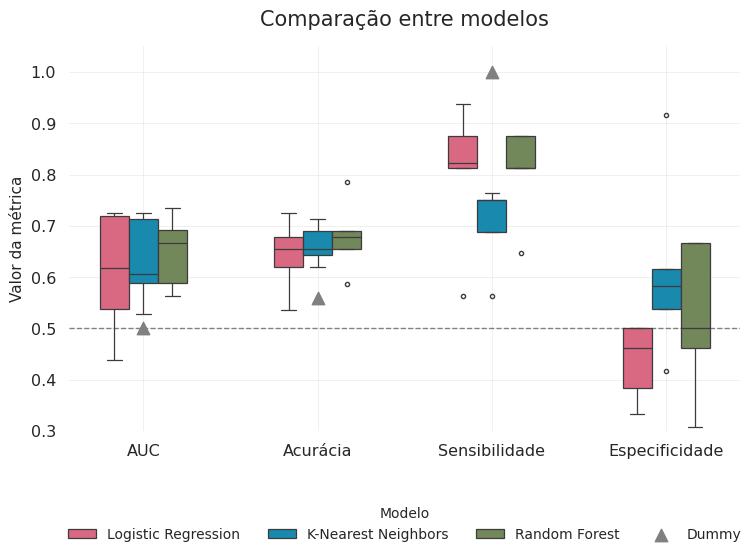

In [ ]:
# Boxplot comparativo (AUC, Acurácia, Sensibilidade)
combined_df = pd.concat(all_fold_metrics, names=['model']).reset_index(level=0)

# Selecionar métricas do dataframe
metrics_of_interest = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
plot_df = combined_df.melt(
    id_vars='model',
    value_vars=metrics_of_interest,
    var_name='metric',
    value_name='value'
)

# Traduzir os nomes
metric_labels = {'AUC': 'AUC',
                 'Accuracy': 'Acurácia',
                 'Sensitivity': 'Sensibilidade',
                 'Specificity': "Especificidade"
                 }

plot_df['metric'] = plot_df['metric'].map(metric_labels)

# Plottar
sns.set_theme(style='whitegrid', font_scale=1.05)
sns.set_palette("muted")

fig, ax = plt.subplots(figsize=(8, 6))

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

# Boxplot comparativo (3 modelos)
sns.boxplot(
    data=plot_df,
    x='metric',
    y='value',
    hue='model',
    palette = roc_colors,
    linewidth=0.9,
    width=0.5,
    fliersize=3,
    ax=ax
)

# Métricas do dummy (triângulos)
ax.scatter(x=0, y=0.50, s=80, marker="^", color='gray', zorder=1, label="Dummy")
ax.scatter(x=1, y=0.56, s=80, marker="^", color='gray', zorder=1)
ax.scatter(x=2, y=1, s=80, marker="^", color='gray', zorder=1)

# Configurações adicionais
ax.set_xlabel('')
ax.set_ylabel('Valor da métrica', fontsize=11)
ax.set_title('Comparação entre modelos', fontsize=15, weight='medium', pad=15)
ax.set_ylim(0.30, 1.05)
ax.grid(axis='y', alpha=0.4, linewidth=0.5)
ax.grid(axis='x', alpha=0.4, linewidth=0.5)

sns.despine(left=True, bottom=True)

ax.legend(
    title='Modelo',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.32),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

<br>

#### **Resumo do LogReg**

* O modelo de **Regressão Logística** apresentou poder discriminativo fraco, mas ainda significativamente melhor que o acaso e que o classificador ingênuo **(AUC=0.607)**. A AUC chegou a superar a faixa de .70 em 2 folds, variando consideravelmente entre os 5 folds.

* A seleção otimizada de features com penalização L1 determinou uma penalização de **C=0.1** como melhor opção para maximização da AUC, resultando na extração de **apenas 21 features dentre as 2557 do espaço total**.

* Com o threshold ótimo segundo o Índice de Youden,
o classificador prioriza drasticamente a detecção de verdadeiros positivos (psicose) à detecção de verdadeiros negativos (controle). **Apesar da boa sensibilidade, sua capacidade de classificar sujeitos saudáveis esteve abaixo do acaso.**
<br>

No geral, o classificador tem pouca utilidade diagnóstica por si só.

<br>

<br>

#### **Resumo do KNN**

* O modelo de **K-Nearest Neighbors** também apresentou poder discriminativo modesto, mas ligeiramente superior ao modelo de Regressão Logística **(AUC=0.632)**, em média.

* A seleção otimizada de features com penalização L1 determinou uma penalização de **C=0.5** como melhor opção para maximização da AUC, resultando na extração de **78 features dentre as 2557 do espaço total**.

* Com o threshold ótimo segundo o Índice de Youden,
o classificador prioriza a detecção de verdadeiros positivos (psicose) à detecção de verdadeiros negativos (controle), mas de maneira **mais balanceada que a Regressão Logística, com especificidade acima do acaso em todos os folds, e com valores mais estáveis.** O classificador KNN foi o modelo mais balanceado entre os três.

* Todas as métricas do KNN estiveram acima do acaso em todos os folds, um sinal interessante de robustez apesar do desempenho fraco.
<br>

No geral, é um classificador modesto com desempenho ligeiramente superior à Regressão Logística e mais estável, mas também com pouca utilidade diagnóstica sozinho.

<br>

<br>

#### **Resumo do Random Forest**

* O modelo de classificação **Random Forest** apresentou desempenho próximo aos demais modelos, com poder discriminativo modesto, superando ligeiramente o modelo de Regressão Logística e KNN com um **AUC≈0.650**, em média.

* A seleção otimizada de features com penalização L1 determinou uma penalização de **C=0.3** como melhor opção para maximização da AUC, resultando na extração de **63 features dentre as 2557 do espaço total**.

* Com o threshold ótimo segundo o Índice de Youden,
o classificador também prioriza muito mais a detecção de verdadeiros positivos (psicose) à detecção de verdadeiros negativos (controle), assim como a Regressão Logística. Apesar de ter apresentado especificidade média próxima do acaso, **sua capacidade de identificar verdadeiros negativos foi superior ao modelo de Regressão Logística na maioria dos folds.** Houve grande oscilação de desempenho entre os folds, nesse caso!
<br>

É um classificador modesto com desempenho ligeiramente superior à Regressão Logística e ao KNN, mas assim como os outros modelos, tem pouca utilidade diagnóstica por si só.

Futuramente, treinamentos com amostras maiores devem ser implementados para comparação do desempenho entre esses modelos.

<br>

<br>

#### **Importância de features**

A seleção de features revelou atributos com **contribuição linear** para a probabilidade predita da classe positiva (psicose).

Dentre as features com maior destaque, estiveram as features estatísticas, de assimetria hemisférica e gradiente topográfico:

* Hjorth complexity
* Assimetria theta/beta
* Assimetria theta/delta
* Assimetria alpha/theta
* Assimetria alpha/beta
* Gradiente frontal-temporal theta/delta
* Gradiente frontal-occipital alpha/beta
* Kurtosis
* First difference
* Second difference

<br>

<br>



---


# **Conclusão**

O projeto teve como objetivo desenvolver modelos de machine learning para **classificação do primeiro episódio psicótico (PEP)** por meio de sinais de eletroencefalograma (EEG), auxiliando no diagnóstico precoce desse quadro. Além disso, buscou identificar atributos com maior contribuição linear para a classe positiva (PEP).

Foram utilizados **dados públicos com 143 indivíduos** (81 PEP, 62 controles). Os sinais foram pré-processados e passaram por engenharia de atributos. A partir disso, três modelos de classificação foram treinados e otimizados com validação cruzada: **Regressão Logística, K-Nearest Neighbors e Random Forest**. Estes foram comparados com um classificador ingênuo (baseline), tendo a AUC como métrica principal.
<br><br>

* Os **atributos estatísticos** extraídos de dados pré-processados de EEG e os **atributos compostos extraídos na engenharia de features** demonstraram contribuição linear para a predição de PEP. **Isso corrobora estudos anteriores quanto a potenciais biomarcadores neurofisiológicos da psicose.**

* Contudo, os modelos de machine learning testados apresentaram poder discriminativo baixo para a classificação de PEP quando treinados com atributos de EEG. **Por um lado, o classificador Random Forest apresentou desempenho superior, em média, aos modelos de Regressão Logística e KNN. Por outro lado, o modelo KNN foi aquele com maior equilíbrio entre sensibilidade e especificidade, embora ainda com métricas baixas.**

* Os modelos apresentaram sensibilidade razoável, mas especificidade inadequada. Ou seja, o trade-off sensibilidade/especificidade dos modelos não foi satisfatório para aplicações clínicas reais, uma vez que os três apresentam **alto risco de falsos positivos**.

* Além disso, esse estudo contou com um dataset de tamanho limitado (n=143), o que provavelmente prejudicou a capacidade dos modelos classificadores de identificar padrões reais e diferenciar sujeitos em PEP de sujeitos saudáveis (*underfitting*). **A amostra limitada também gerou certa instabilidade no desempenho dos modelos, quando avaliados pela validação cruzada.**

* A incorporação de variáveis "fenotípicas", como dados demográficos, escalas comportamentais, testes cognitivos e observação clínica devem ser testadas em modelos de classificação, onde dados de EEG podem funcionar como **atributos complementares para o aprimoramento do poder discriminativo desses modelos**. Para implementar esse tipo de variável clínica, deve-se ter especial atenção para o problema da circularidade diagnóstica.

* Por fim, outras famílias de modelos podem ser implementadas com otimização de hiperparâmetros mais granular e amostras maiores. Esse é o caminho mais direto para o desenvolvimento de classificadores robustos com dados de EEG.

<br>



---


# **Referências**

Colombo, M. A., Comanducci, A., Casarotto, S., Derchi, C. C., Annen, J., Viganò, A., & Rosanova, M. (2023). Beyond alpha power: EEG spatial and spectral gradients robustly stratify disorders of consciousness. Cerebral cortex, 33(11), 7193-7210.
<br>

Donoghue, T., Dominguez, J., & Voytek, B. (2020). Electrophysiological Frequency Band Ratio Measures Conflate Periodic and Aperiodic Neural Activity. eNeuro, 7(6), ENEURO.0192-20.2020.
<br>

Drążyk, D., Przewrocki, K., Górska-Klimowska, U. et al. (2024). Distinct Spectral Profiles of Awake Resting EEG in Disorders of Consciousness: The Role of Frequency and Topography of Oscillations. Brain Topogr 37, 138–151.
<br>

Gengeç Benli, Ş. (2023). Classification of First-Episode Psychosis with EEG Signals: ciSSA and Machine Learning Approach. Biomedicines, 11(12), 3223.
<br>

Gordon, E., Palmer, D. M., & Cooper, N. (2010). EEG alpha asymmetry in schizophrenia, depression, PTSD, panic disorder, ADHD and conduct disorder. Clinical EEG and neuroscience, 41(4), 178-183.
<br>

Gouvea, E. S., Noto, C., Bonadia, B., Senço, N. M. de, Gadelha, A., Bressan, R. A., & Cordeiro, Q. (2014). Primeiro episódio psicótico: atendimento de emergência. Debates Em Psiquiatria, 4(6), 16–22.
<br>

Howells, F. M., Temmingh, H. S., Hsieh, J. H., van Dijen, A. V., Baldwin, D. S., & Stein, D. J. (2018). Electroencephalographic delta/alpha frequency activity differentiates psychotic disorders: a study of schizophrenia, bipolar disorder and methamphetamine-induced psychotic disorder. Translational psychiatry, 8(1), 75.
<br>

Jia, S., Liu, W., Zhao, Q., Yun, S., Xin, X., Liu, C., & Wang, X. (2026). Hemispheric asymmetry in depressive symptoms is associated with sex-divergent functional brain connectivity patterns. Iscience, 29(4).
<br>

Naeim, M., & Narimani, M. (2026). EEG-based biomarkers for psychosis: Comparative performance of support vector machines and deep neural networks. Biological Psychology, 109232.
<br>

Perrottelli A, Giordano GM, Brando F, Giuliani L and Mucci A (2021) EEG-Based Measures in At-Risk Mental State and Early Stages of Schizophrenia: A Systematic Review. Front. Psychiatry 12:653642.
<br>

Redwan, S.M., Uddin, M.P., Ulhaq, A. et al.  (2024). Power spectral density-based resting-state EEG classification of first-episode psychosis. Sci Rep 14, 15154.
<br><br>

*Os modelos de linguagem DeepSeek V4 e Claude Sonnet 5 foram utilizados para otimização, formatação e revisão do código implementado nesse projeto.*